# Analisi dei risultati — 3 modelli x 5 benchmark

Notebook di analisi dei risultati salvati in `results/`.

**Modelli:** `claude-opus-4.7` (LLM), `deepseek-v4-pro` (MoE), `ministral-8b` (SLM)
**Benchmark:** HumanEval, MBPP, DS-1000, MultiPL-E, Plot2Code

Contenuto:
1. Caricamento dei dataset `results` con pandas
2. Descrizione **tabulare** dei risultati per tutti e 5 i benchmark
3. Grafici con **plotnine** (stile `ggplot + aes + geom_*`)
4. **Scatterplot** problemi risolti (blu) / non risolti (rosso) vs punteggio CodeBLEU — matrice 2x2 per modello
5. **MultiPL-E**: grafico a barre dei problemi risolti per linguaggio, con icona del linguaggio


## 1. Setup e caricamento dei dataset `results`

In [1]:
import warnings
from pathlib import Path

import pandas as pd
from plotnine import (
    ggplot, aes, geom_bar, geom_point, geom_jitter, geom_text, facet_wrap,
    position_dodge, scale_color_manual, scale_fill_manual, labs,
    theme, theme_gray, element_text, element_rect, coord_flip,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

# La cartella results sta un livello sopra a questo notebook (analysis/)
RESULTS_DIR = (Path.cwd().parent / "results")
if not RESULTS_DIR.exists():               # fallback se il notebook gira dalla root
    RESULTS_DIR = Path.cwd() / "results"
assert RESULTS_DIR.exists(), f"results non trovata: {RESULTS_DIR}"

MODELS = ["claude-opus-4.7", "deepseek-v4-pro", "ministral-8b"]
BENCHMARKS = ["humaneval", "mbpp", "ds1000", "multipl-e", "plot2code"]
# Benchmark per cui e' stato calcolato il punteggio CodeBLEU (4 -> matrice 2x2)
CODEBLEU_BENCHMARKS = ["humaneval", "mbpp", "ds1000", "plot2code"]

print("results:", RESULTS_DIR)


results: C:\Users\miane\OneDrive\Desktop\Claude_Code_Evaluation\Claude-Coding-Evaluation\results


### 1.1 Caricamento in un unico DataFrame

Ogni risultato e' un CSV in `results/<modello>/<benchmark>/<modello>.csv`.
Li uniamo in un unico DataFrame aggiungendo le colonne `model`, `benchmark` e
`solved` (booleano: `pass@1 == "passed"`).

In [2]:
def load_one(model: str, benchmark: str) -> pd.DataFrame:
    path = RESULTS_DIR / model / benchmark / f"{model}.csv"
    df = pd.read_csv(path)
    df.columns = [c.lstrip("\ufeff") for c in df.columns]  # rimuove BOM
    df["model"] = model
    df["benchmark"] = benchmark
    df["solved"] = df["pass@1"].astype(str).str.strip().eq("passed")
    return df


frames = []
for m in MODELS:
    for b in BENCHMARKS:
        p = RESULTS_DIR / m / b / f"{m}.csv"
        if p.exists():
            frames.append(load_one(m, b))
        else:
            print("MANCANTE:", p)

data = pd.concat(frames, ignore_index=True)
print("Righe totali:", len(data))
data[["model", "benchmark", "task_id", "pass@1", "solved"]].head()


Righe totali: 13119


,model,benchmark,task_id,pass@1,solved
0,claude-opus-4.7,humaneval,HumanEval/0,passed,True
1,claude-opus-4.7,humaneval,HumanEval/1,passed,True
2,claude-opus-4.7,humaneval,HumanEval/2,passed,True
3,claude-opus-4.7,humaneval,HumanEval/3,passed,True
4,claude-opus-4.7,humaneval,HumanEval/4,passed,True


## 2. Descrizione tabulare dei risultati (tutti e 5 i benchmark)

### 2.1 Tabella riassuntiva: pass@1 (%) per modello x benchmark
Per ogni coppia modello/benchmark: numero di problemi, risolti e **pass@1** in percentuale.

In [3]:
summary = (
    data.groupby(["model", "benchmark"])
        .agg(n=("solved", "size"),
             solved=("solved", "sum"))
        .reset_index()
)
summary["pass@1_%"] = (100 * summary["solved"] / summary["n"]).round(1)

# Pivot leggibile: righe = modello, colonne = benchmark, valori = pass@1 %
pass_pivot = (
    summary.pivot(index="model", columns="benchmark", values="pass@1_%")
           .reindex(index=MODELS, columns=BENCHMARKS)
)
pass_pivot["MEDIA"] = pass_pivot.mean(axis=1).round(1)
print("pass@1 (%) per modello x benchmark")
pass_pivot


pass@1 (%) per modello x benchmark


benchmark,humaneval,mbpp,ds1000,multipl-e,plot2code,MEDIA
model,,,,,,
claude-opus-4.7,99.4,91.8,81.9,86.2,81.5,88.2
deepseek-v4-pro,90.2,82.4,61.6,77.1,70.9,76.4
ministral-8b,76.2,67.2,35.9,55.8,59.0,58.8


### 2.2 Tabella CodeBLEU medio (solo benchmark con CodeBLEU)
CodeBLEU misura la similarita' del codice generato rispetto alla soluzione di riferimento;
e' disponibile per HumanEval, MBPP, DS-1000 e Plot2Code (non per MultiPL-E).

In [4]:
cb = data[data["benchmark"].isin(CODEBLEU_BENCHMARKS)].copy()
cb["codebleu"] = pd.to_numeric(cb["codebleu"], errors="coerce")

codebleu_pivot = (
    cb.groupby(["model", "benchmark"])["codebleu"].mean()
      .unstack("benchmark")
      .reindex(index=MODELS, columns=CODEBLEU_BENCHMARKS)
      .round(3)
)
print("CodeBLEU medio per modello x benchmark")
codebleu_pivot


CodeBLEU medio per modello x benchmark


benchmark,humaneval,mbpp,ds1000,plot2code
model,,,,
claude-opus-4.7,0.409,0.256,0.486,0.381
deepseek-v4-pro,0.404,0.254,0.341,0.376
ministral-8b,0.358,0.241,0.290,0.312


### 2.3 Tabella riassuntiva completa (una riga per modello x benchmark)
Per ogni modello e benchmark: **pass@1 totale** come `risolti / totali` (piu' la percentuale) e il
**CodeBLEU medio**. Per **MultiPL-E** il CodeBLEU non e' calcolato (multilinguaggio, senza soluzione
gold) -> `n/d`.

In [5]:
cb_mean = (
    cb.groupby(["model", "benchmark"])["codebleu"].mean().round(3).reset_index()
)
tabella = summary.merge(cb_mean, on=["model", "benchmark"], how="left")

# pass@1 totale = risolti / totali
tabella["pass@1 (risolti/totali)"] = (
    tabella["solved"].astype(int).astype(str) + " / " + tabella["n"].astype(str)
)
# CodeBLEU medio: 'n/d' dove non calcolato (MultiPL-E / NaN)
tabella["codebleu_medio"] = tabella["codebleu"].round(3).astype("object")
tabella.loc[tabella["benchmark"] == "multipl-e", "codebleu_medio"] = "n/d"
tabella["codebleu_medio"] = tabella["codebleu_medio"].fillna("n/d")

# ordinamento e colonne finali
tabella["benchmark"] = pd.Categorical(tabella["benchmark"], BENCHMARKS, ordered=True)
tabella["model"] = pd.Categorical(tabella["model"], MODELS, ordered=True)
tabella = tabella.sort_values(["model", "benchmark"]).reset_index(drop=True)
tabella = tabella[["model", "benchmark",
                   "pass@1 (risolti/totali)", "pass@1_%", "codebleu_medio"]]
tabella


,model,benchmark,pass@1 (risolti/totali),pass@1_%,codebleu_medio
0,claude-opus-4.7,humaneval,163 / 164,99.4,0.409
1,claude-opus-4.7,mbpp,459 / 500,91.8,0.256
2,claude-opus-4.7,ds1000,782 / 955,81.9,0.486
3,claude-opus-4.7,multipl-e,2056 / 2386,86.2,n/d
4,claude-opus-4.7,plot2code,300 / 368,81.5,0.381
5,deepseek-v4-pro,humaneval,148 / 164,90.2,0.404
6,deepseek-v4-pro,mbpp,412 / 500,82.4,0.254
7,deepseek-v4-pro,ds1000,588 / 955,61.6,0.341
8,deepseek-v4-pro,multipl-e,1840 / 2386,77.1,n/d
9,deepseek-v4-pro,plot2code,261 / 368,70.9,0.376


## 3. Grafici con plotnine

### 3.1 pass@1 per benchmark e modello (grafico a barre)
Stile `ggplot(...) + aes(...) + geom_bar(...)`.

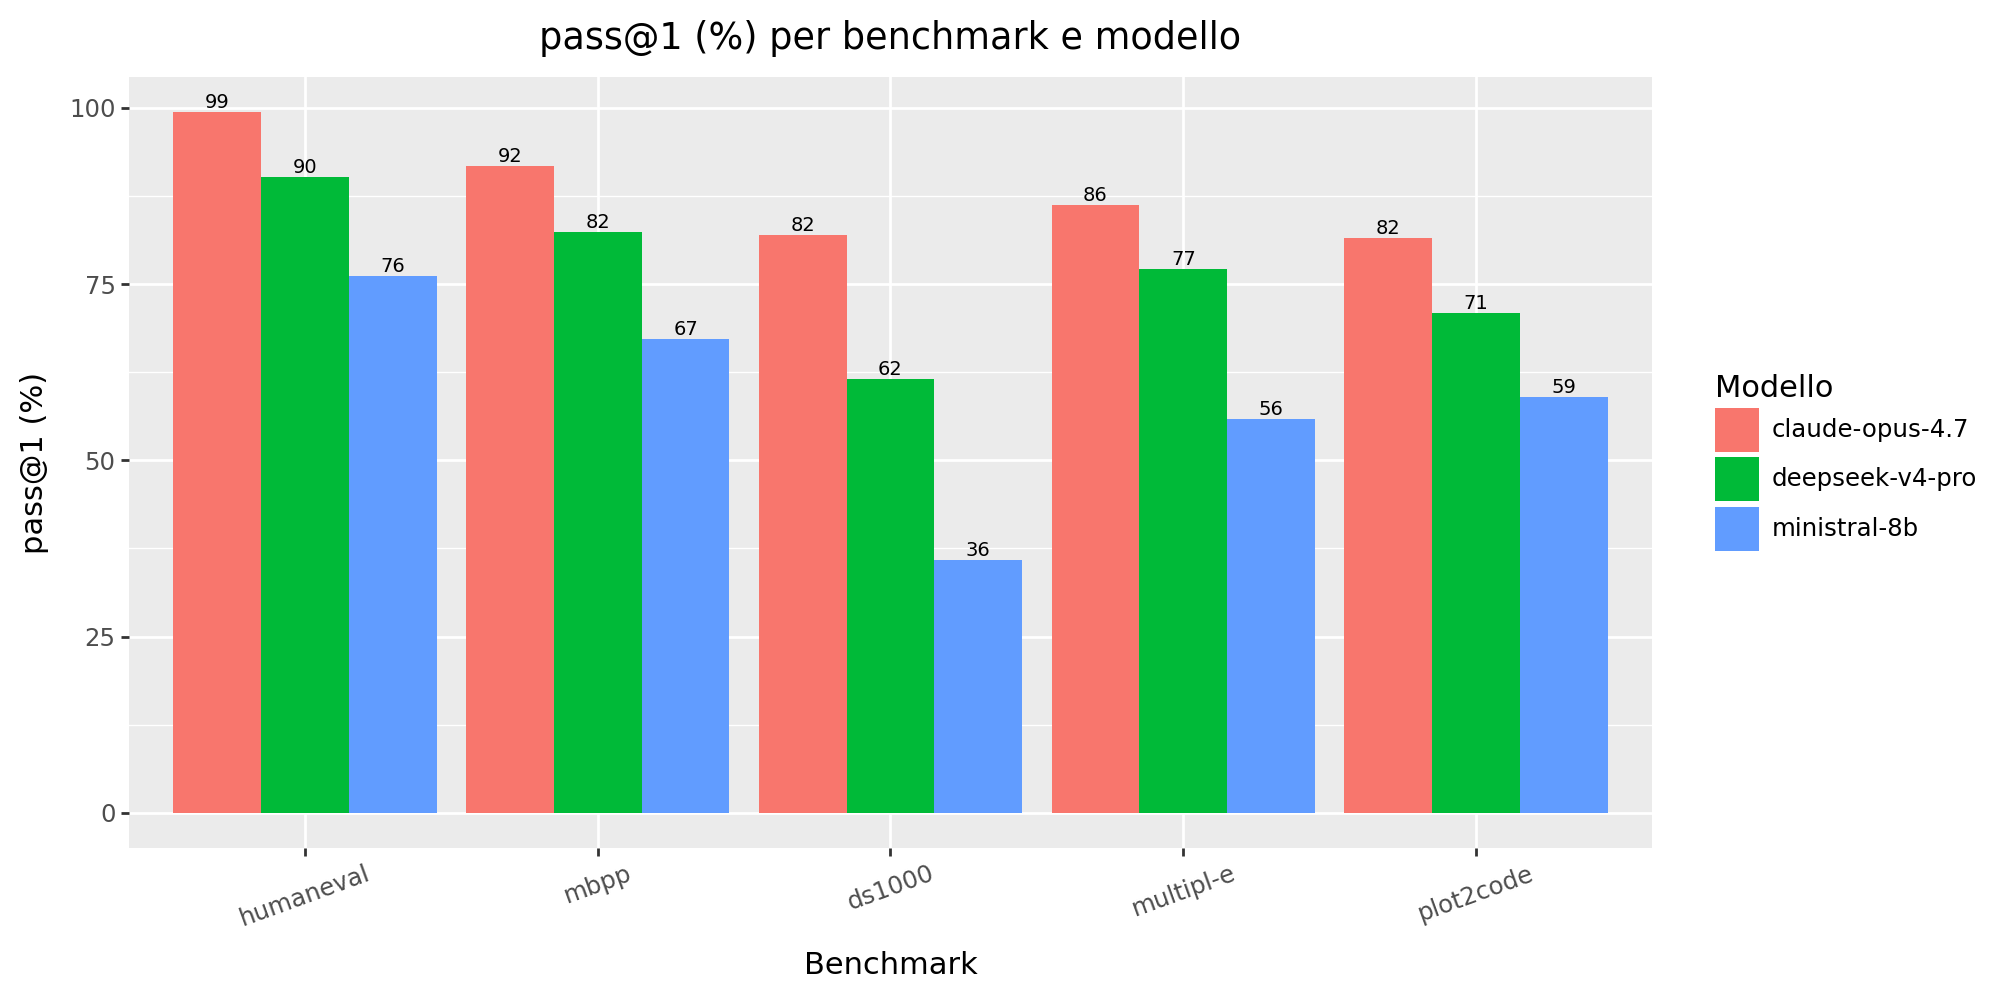

In [6]:
plot_df = summary.copy()
plot_df["benchmark"] = pd.Categorical(plot_df["benchmark"], BENCHMARKS, ordered=True)

p_pass = (
    ggplot(plot_df)
    + aes(x="benchmark", y="pass@1_%", fill="model")
    + geom_bar(stat="identity", position=position_dodge(width=0.9))
    + geom_text(aes(label="pass@1_%"), position=position_dodge(width=0.9),
                va="bottom", size=7, format_string="{:.0f}")
    + labs(title="pass@1 (%) per benchmark e modello",
           x="Benchmark", y="pass@1 (%)", fill="Modello")
    + theme_gray()
    + theme(figure_size=(10, 5), axis_text_x=element_text(rotation=20))
)
p_pass


## 4. Scatterplot: risolti (blu) vs non risolti (rosso) per CodeBLEU

Per ogni modello una **matrice 2x2** (`facet_wrap`) con i 4 benchmark che hanno il punteggio
CodeBLEU. **Asse X = punteggio CodeBLEU**, **asse Y = id del problema**, **colore (legenda) = esito**
(blu = risolto, rosso = non risolto).

> **Come si legge.** Ogni punto e' un singolo problema: la sua posizione orizzontale e' il CodeBLEU,
> quella verticale e' l'id del problema (serve solo a dare a ciascun problema una riga propria, cosi'
> i punti non si sovrappongono). Si guarda **lungo l'asse X**: se i punti **rossi** (non risolti) sono
> spostati a sinistra rispetto ai **blu** (risolti), i problemi falliti tendono a produrre codice con
> CodeBLEU piu' basso (evidente soprattutto in DS-1000 e Plot2Code).

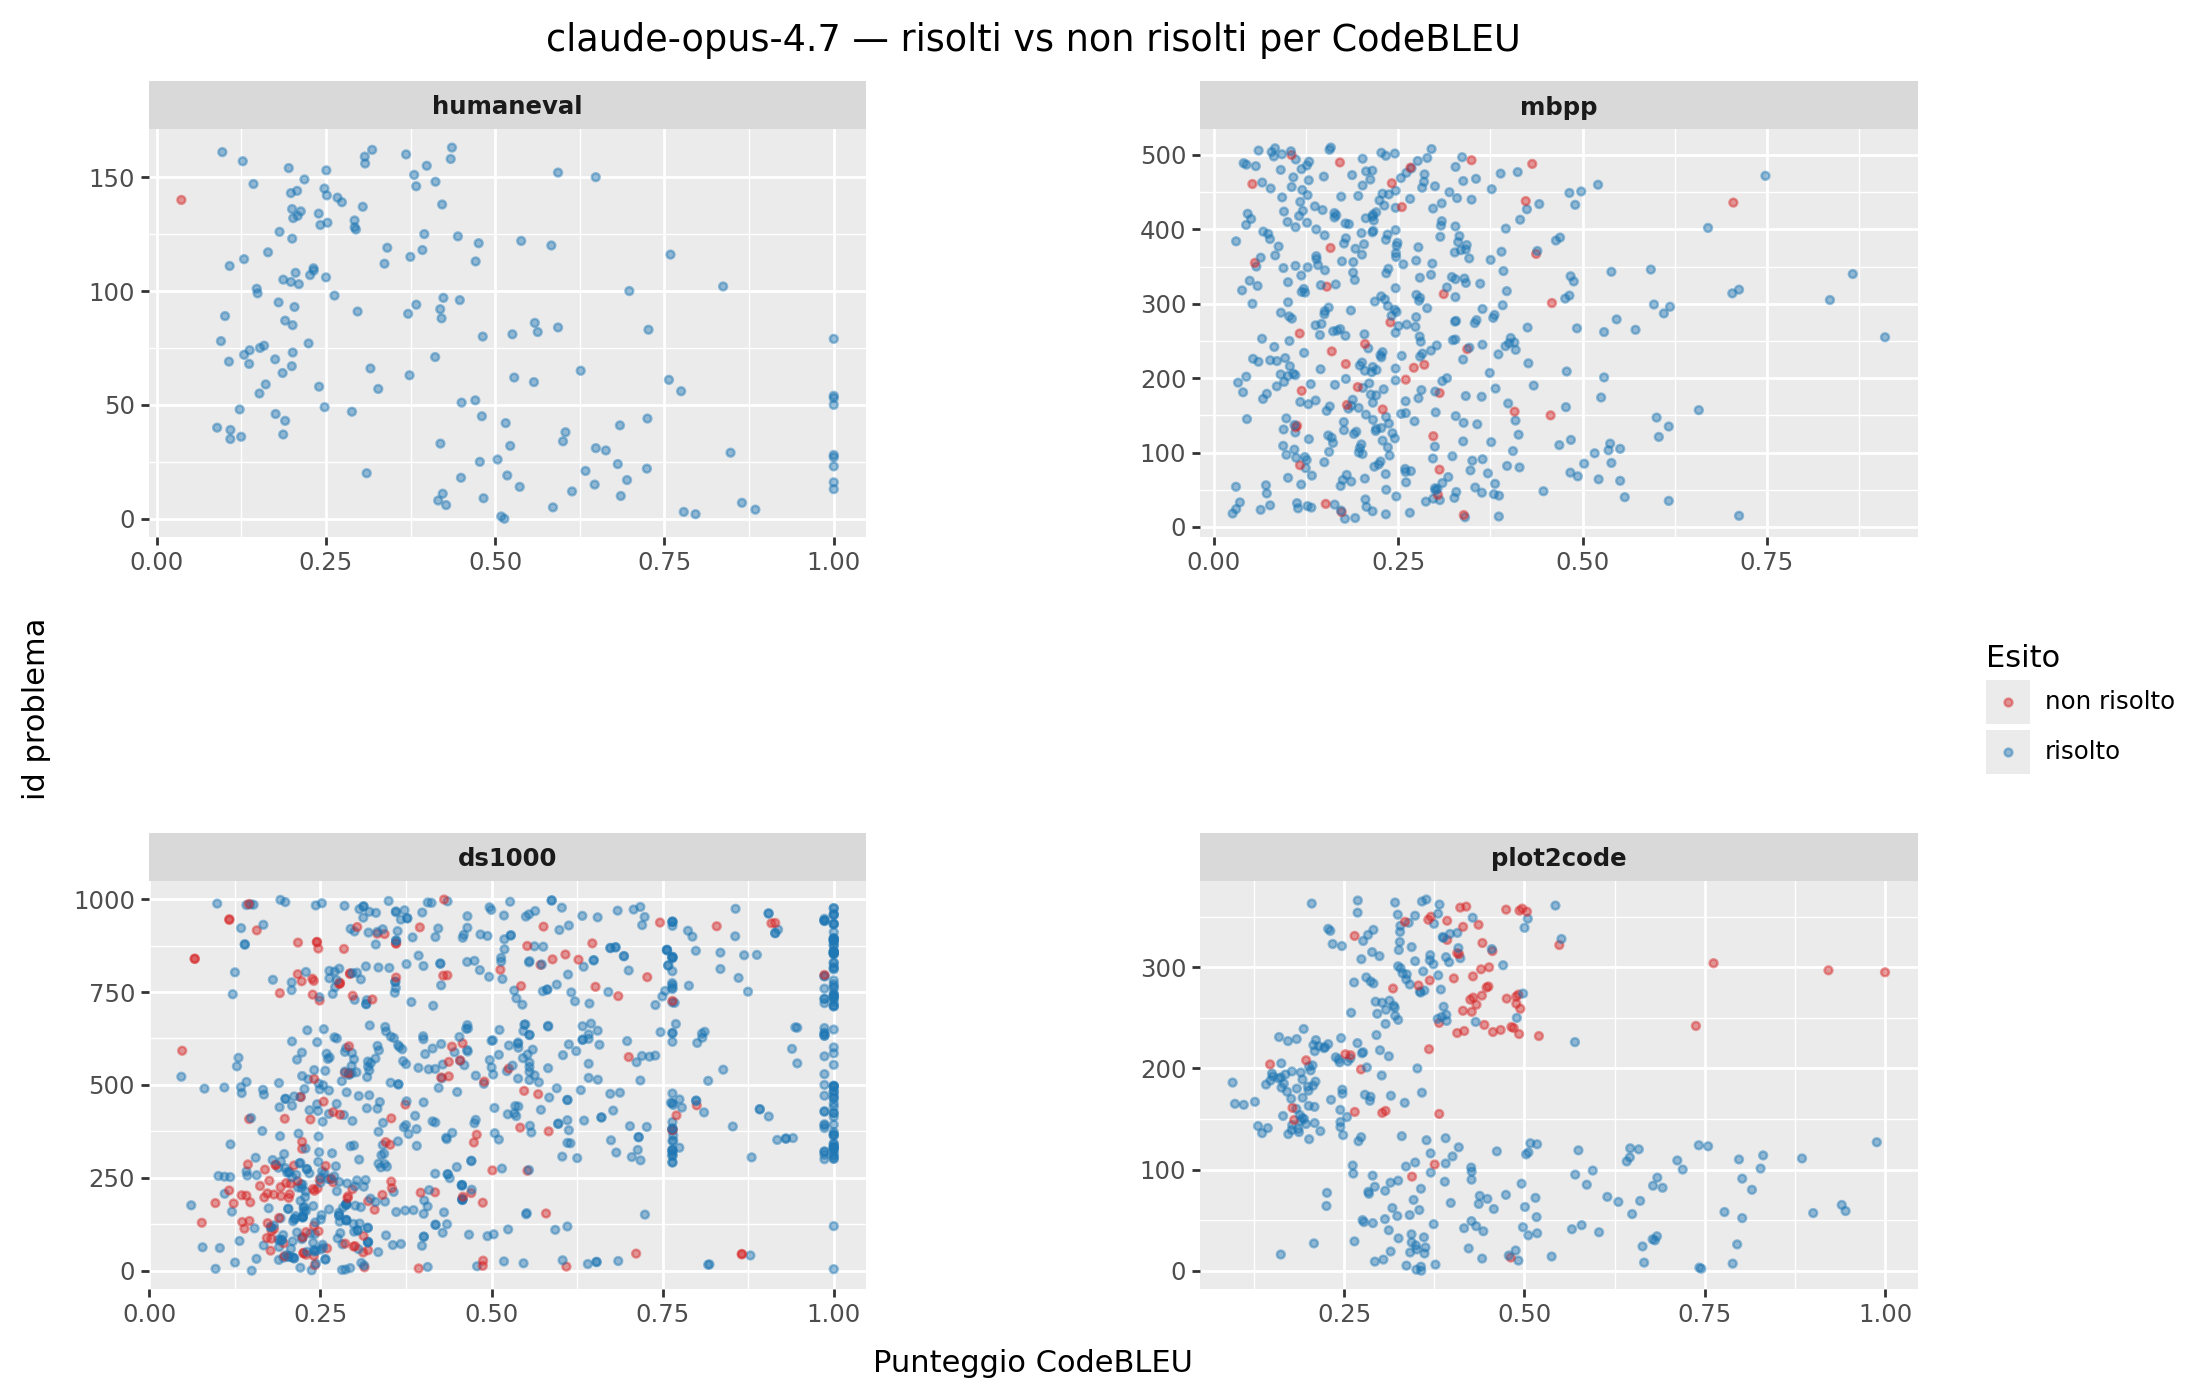

In [7]:
cb_plot = cb.copy()
cb_plot["esito"] = cb_plot["solved"].map({True: "risolto", False: "non risolto"})
cb_plot["benchmark"] = pd.Categorical(cb_plot["benchmark"], CODEBLEU_BENCHMARKS, ordered=True)

# id numerico del problema = numero finale del task_id (HumanEval/0 -> 0, ds1000 '12' -> 12, ...)
cb_plot["pid"] = cb_plot["task_id"].astype(str).str.extract(r"(\d+)$").astype(float)
# fallback per eventuali task_id senza numero: ordinale per benchmark
_missing = cb_plot["pid"].isna()
if _missing.any():
    cb_plot.loc[_missing, "pid"] = (
        cb_plot[_missing].groupby("benchmark", observed=True).cumcount().astype(float)
    )

COLORS = {"risolto": "#1f77b4", "non risolto": "#d62728"}  # blu / rosso


def scatter_for_model(model: str):
    d = cb_plot[cb_plot["model"] == model]
    return (
        ggplot(d)
        + aes(x="codebleu", y="pid", color="esito")
        + geom_point(alpha=0.45, size=1.1)
        + facet_wrap("benchmark", ncol=2, scales="free")
        + scale_color_manual(values=COLORS)
        + labs(title=f"{model} — risolti vs non risolti per CodeBLEU",
               x="Punteggio CodeBLEU", y="id problema", color="Esito")
        + theme_gray()
        + theme(figure_size=(11, 7),
                panel_spacing=0.12,                                   # stacco tra i 4 riquadri della matrice 2x2
                strip_text=element_text(weight="bold"))
    )


scatter_for_model("claude-opus-4.7")


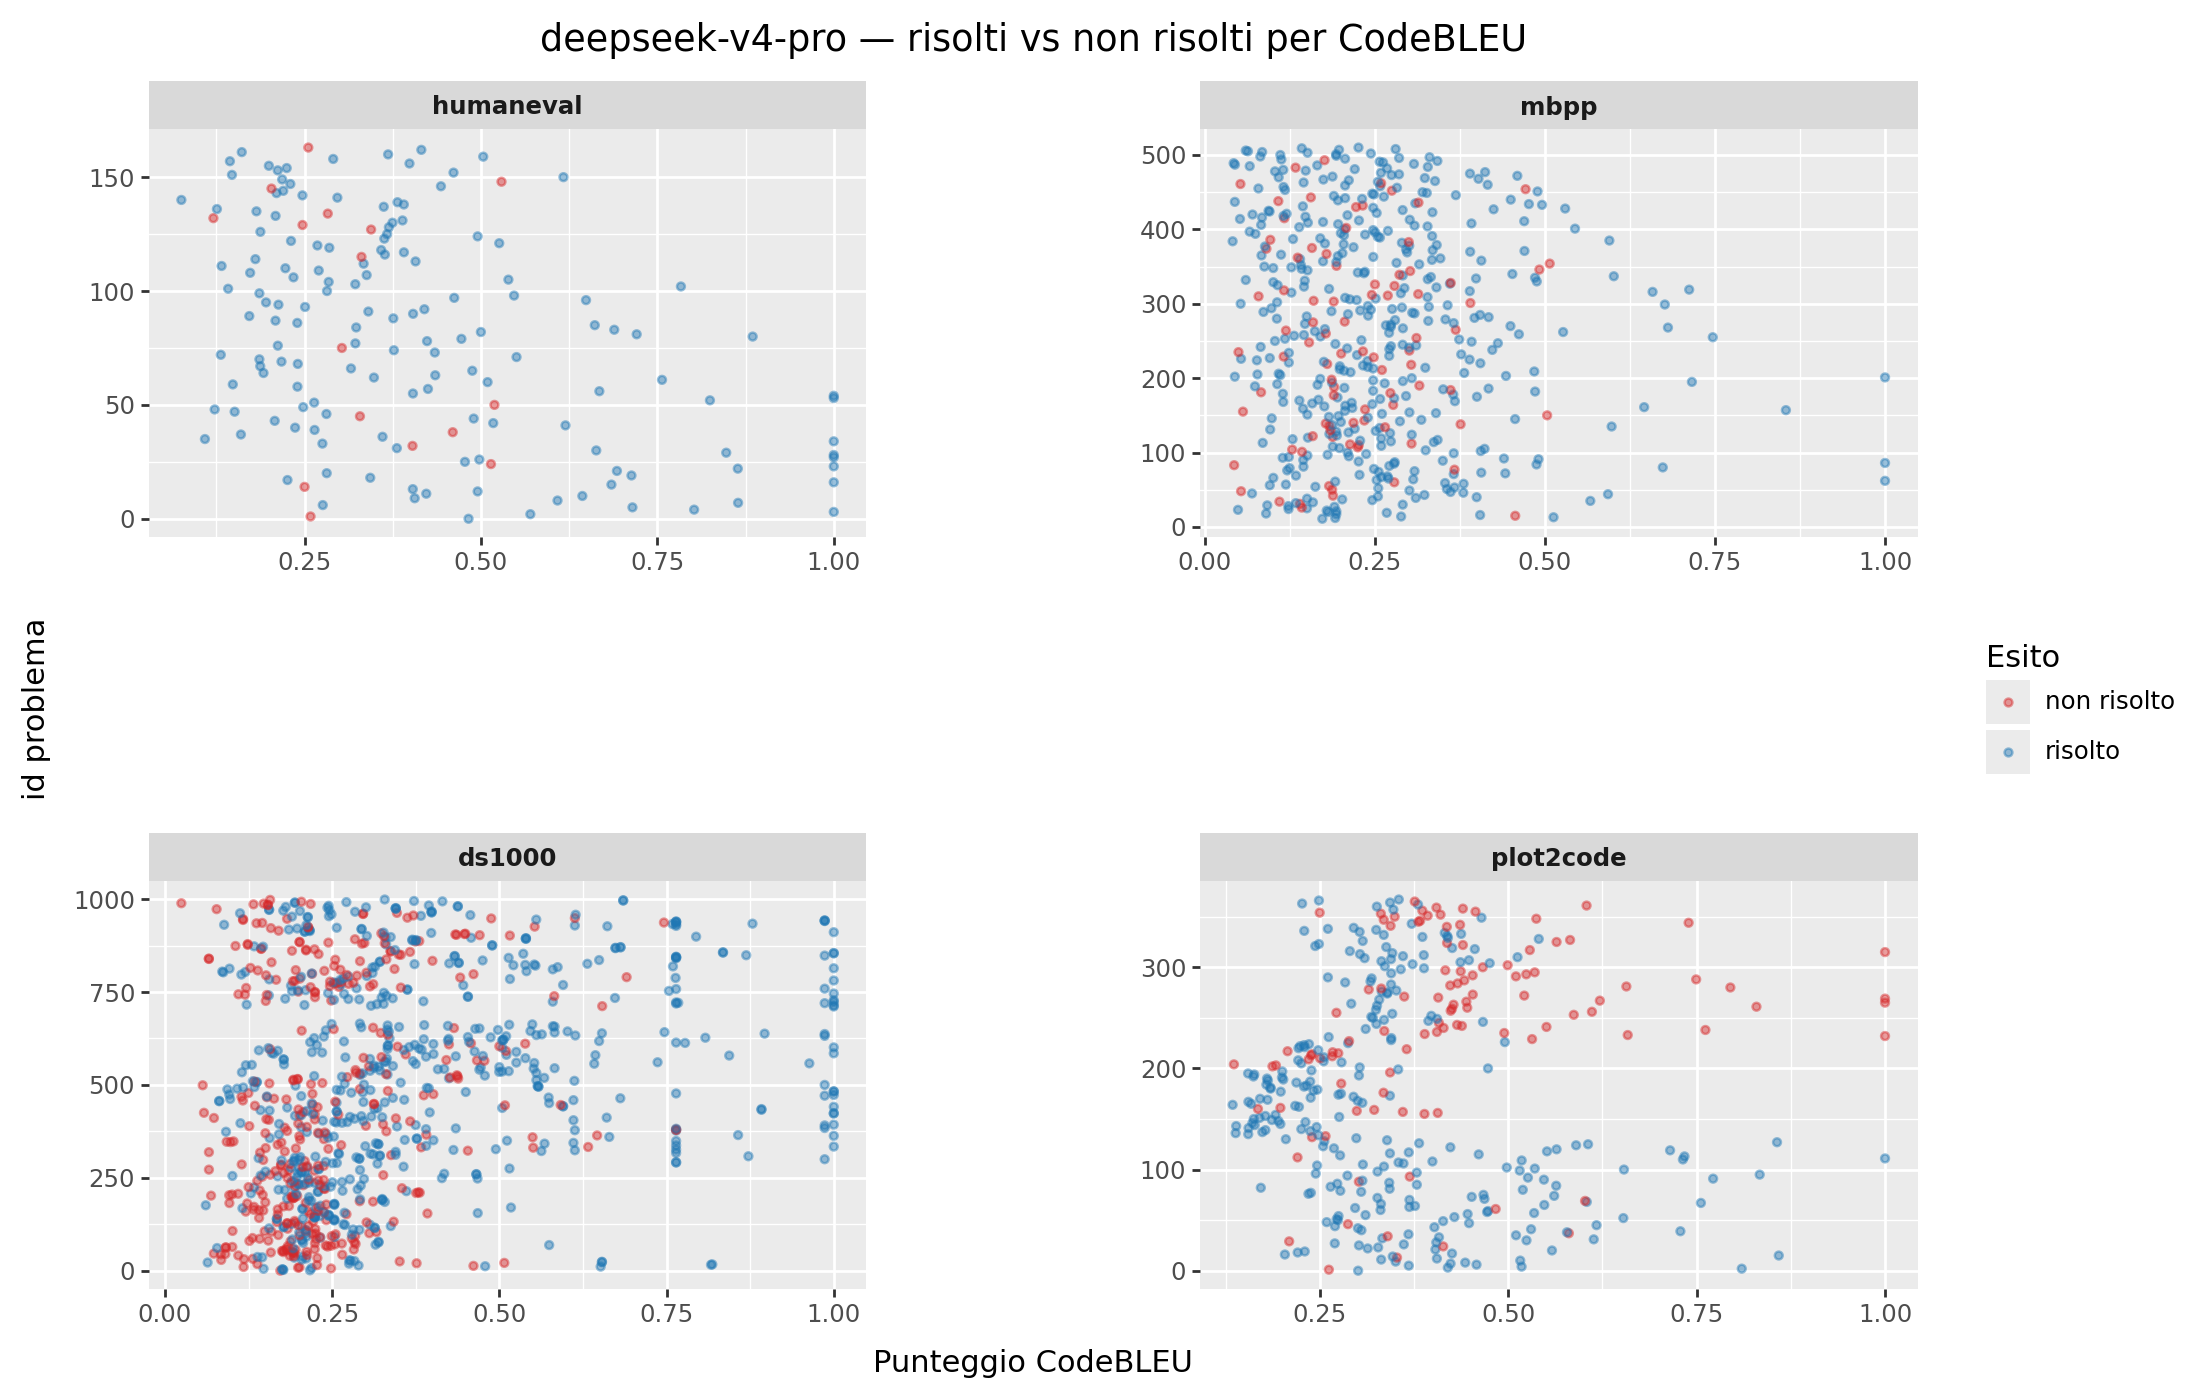

In [8]:
scatter_for_model("deepseek-v4-pro")

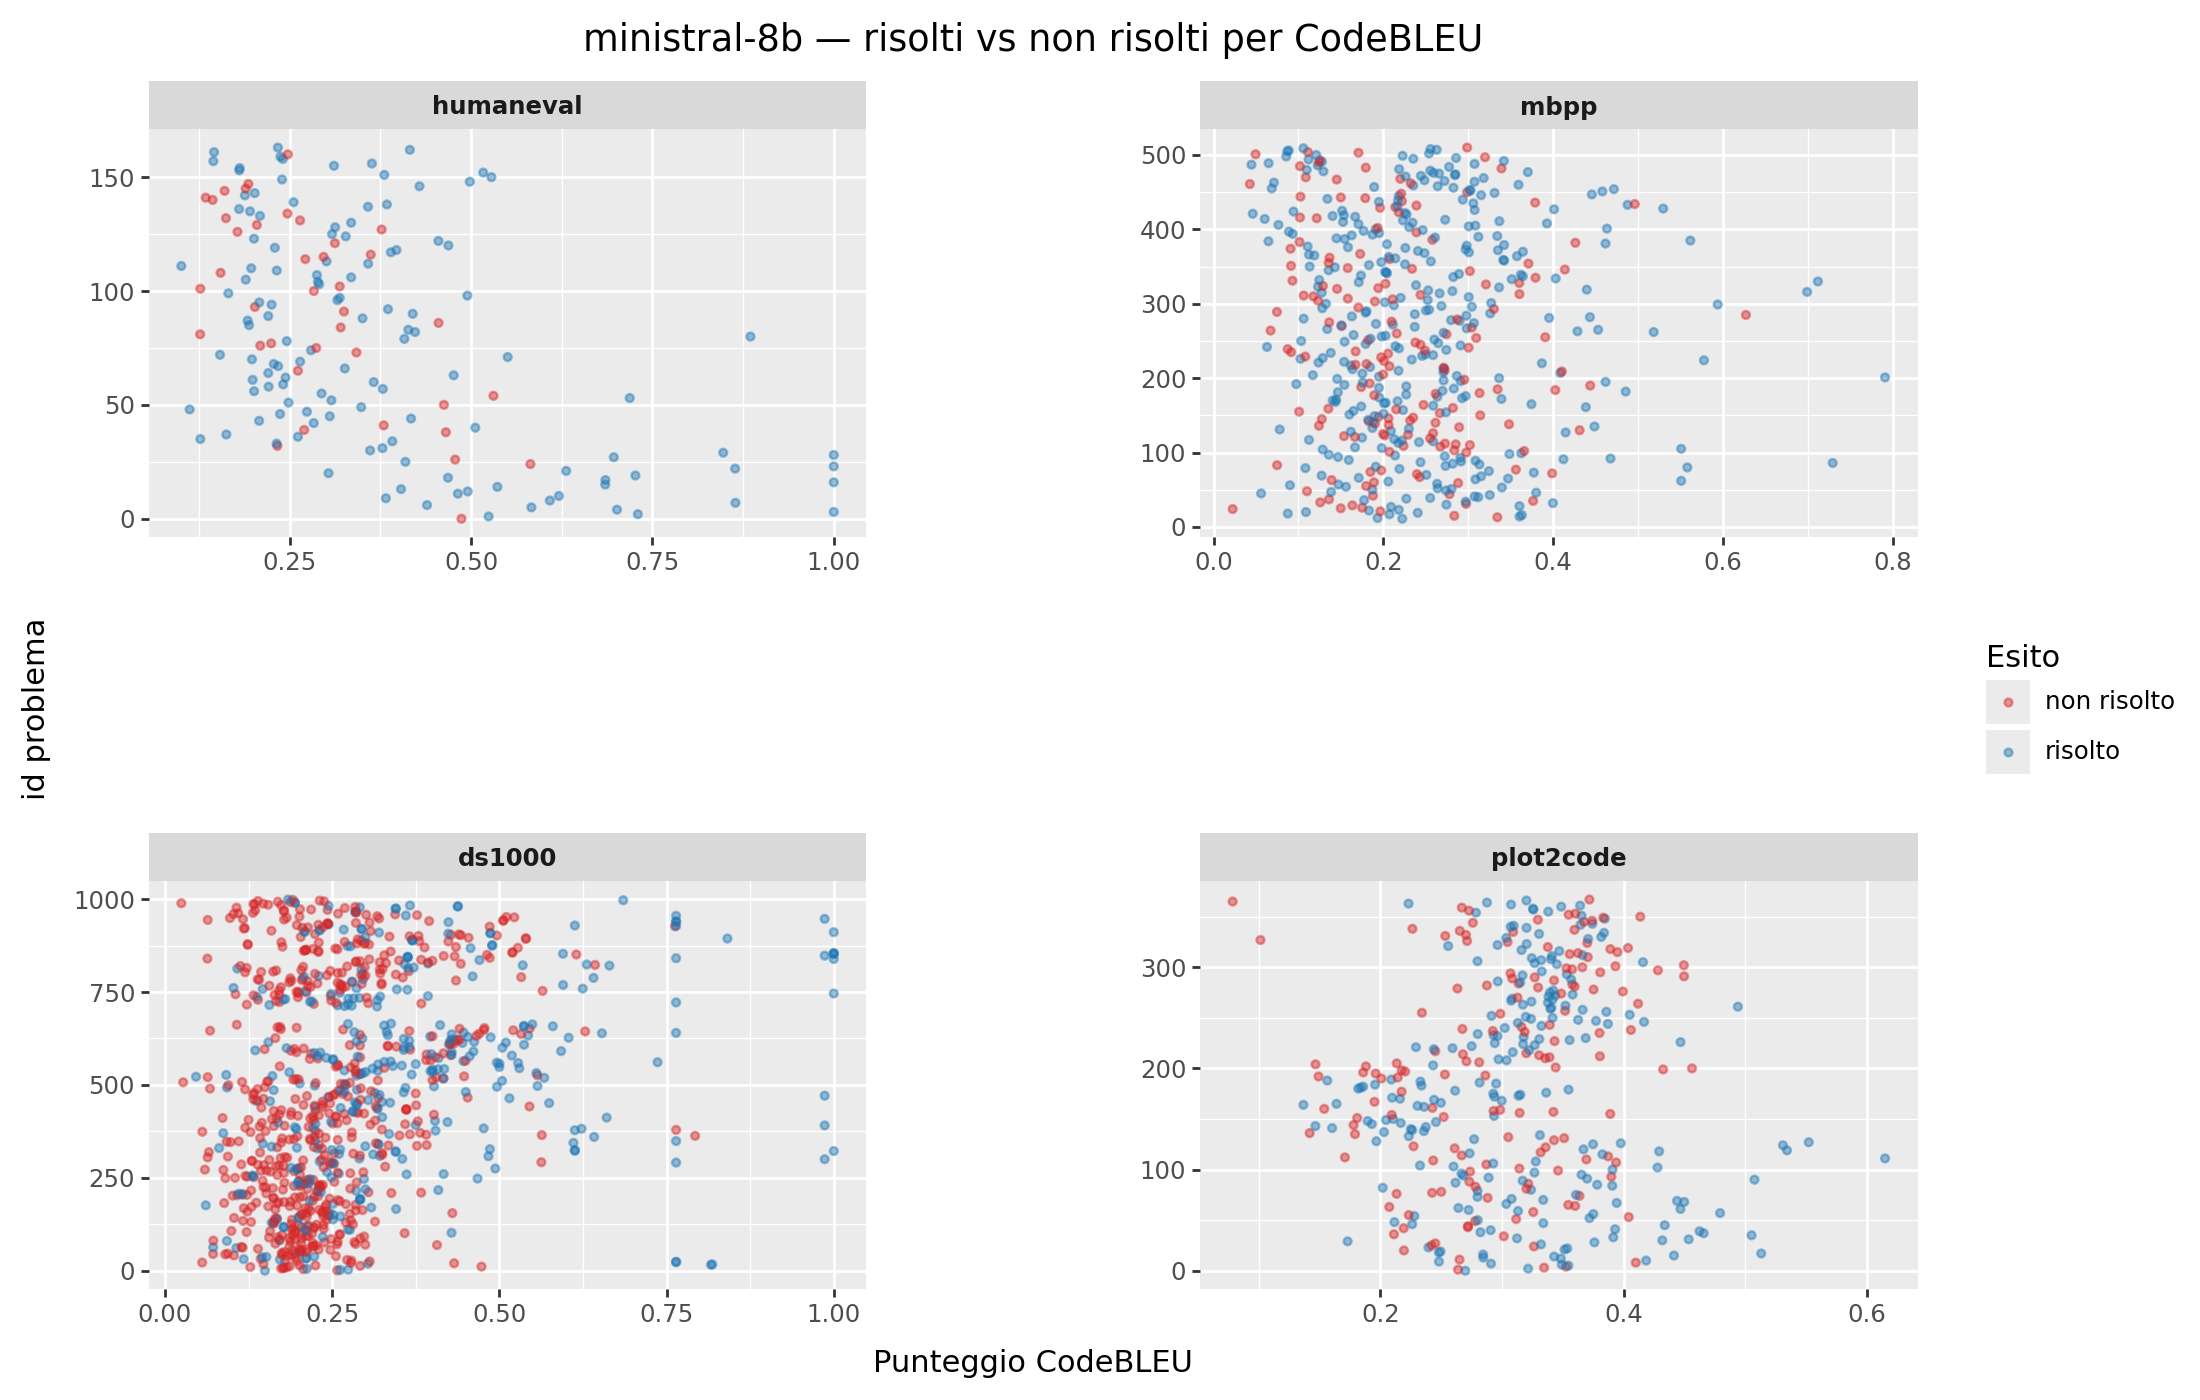

In [9]:
scatter_for_model("ministral-8b")

## 5. MultiPL-E: problemi risolti per linguaggio

Problemi **risolti** per ciascun linguaggio di programmazione, con il dettaglio per modello.
Prima prepariamo i dati, poi il grafico con le icone dei linguaggi.

In [10]:
mpe = data[data["benchmark"] == "multipl-e"].copy()
solved_by_lang = (
    mpe[mpe["solved"]]
    .groupby(["language", "model"]).size()
    .reset_index(name="risolti")
)
# ordine linguaggi per totale risolti (somma sui modelli)
order = (solved_by_lang.groupby("language")["risolti"].sum()
         .sort_values(ascending=False).index.tolist())
solved_by_lang["language"] = pd.Categorical(solved_by_lang["language"], order, ordered=True)
solved_by_lang.head()


,language,model,risolti
0,cpp,claude-opus-4.7,152
1,cpp,deepseek-v4-pro,137
2,cpp,ministral-8b,112
3,cs,claude-opus-4.7,107
4,cs,deepseek-v4-pro,100


### 5.1 Grafico con icone dei linguaggi (dettaglio per modello)
Barre **raggruppate per modello**: per ogni linguaggio si vedono i problemi risolti da ciascun
modello (claude / deepseek / ministral), con il conteggio sopra ogni barra. Logo del linguaggio sotto
ad ogni gruppo (icons8, cache in `analysis/icons/`; per `lua`, non disponibile, si usa il nome).
Il numero totale di problemi per linguaggio (per modello) e' ~159.

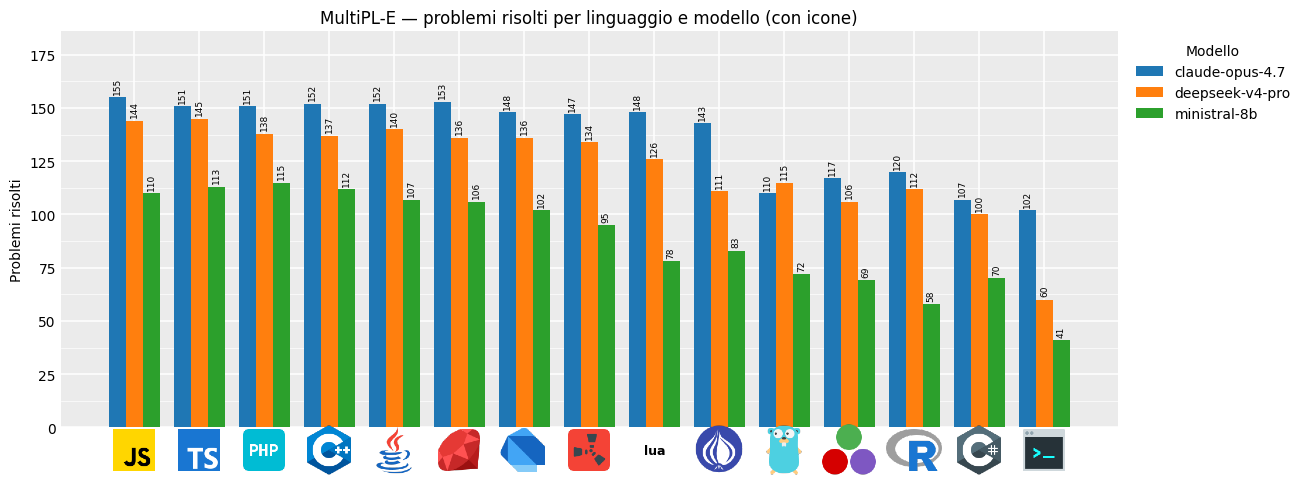

In [11]:
import urllib.request
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.ticker import AutoMinorLocator
from PIL import Image

ICON_DIR = Path.cwd() / "icons"
ICON_DIR.mkdir(exist_ok=True)

# slug icons8 per ogni linguaggio del benchmark (sigla -> slug)
ICON_SLUG = {
    "cpp": "c-plus-plus-logo", "cs": "c-sharp-logo", "dart": "dart",
    "go": "golang", "java": "java-coffee-cup-logo", "jl": "julia",
    "js": "javascript", "php": "php", "pl": "perl", "r": "r-project",
    "rb": "ruby-programming-language", "rs": "rust", "sh": "console",
    "ts": "typescript",   # 'lua' non disponibile -> fallback testuale
}


def icon_path(lang: str):
    slug = ICON_SLUG.get(lang)
    if slug is None:
        return None
    fp = ICON_DIR / f"{lang}.png"
    if not fp.exists():
        url = f"https://img.icons8.com/color/96/{slug}.png"
        try:
            urllib.request.urlretrieve(url, fp)
        except Exception as e:
            print("icona non scaricata:", lang, e)
            return None
    return fp


import numpy as np

# risolti per linguaggio E per modello (pivot)
piv = (solved_by_lang.pivot(index="language", columns="model", values="risolti")
       .reindex(index=order, columns=MODELS).fillna(0).astype(int))

# --- palette coerente col tema default di plotnine (theme_gray) ---
PANEL_GRAY = "#EBEBEB"   # grigio del pannello ggplot
MODEL_COLORS = {"claude-opus-4.7": "#1f77b4",   # blu
                "deepseek-v4-pro": "#ff7f0e",   # arancio
                "ministral-8b": "#2ca02c"}      # verde

x = np.arange(len(order))
width = 0.26
ymax = int(piv.values.max())

fig, ax = plt.subplots(figsize=(14, 5.5))
fig.patch.set_facecolor("white")          # sfondo figura bianco (come ggplot)
ax.set_facecolor(PANEL_GRAY)              # pannello grigio
for j, m in enumerate(MODELS):
    offs = (j - 1) * width                # 3 barre affiancate centrate sul linguaggio
    ax.bar(x + offs, piv[m].values, width=width, color=MODEL_COLORS[m],
           zorder=3, label=m)
    for xi, val in zip(x + offs, piv[m].values):
        ax.text(xi, val + ymax * 0.01, str(int(val)), ha="center", va="bottom",
                fontsize=6.5, rotation=90)
ax.set_xticks(list(x))
ax.set_xticklabels([])                      # le etichette le mettiamo come icone
ax.set_ylabel("Problemi risolti")
ax.set_title("MultiPL-E — problemi risolti per linguaggio e modello (con icone)")
ax.set_ylim(0, ymax * 1.20)
# griglia bianca "a quadretti" come theme_gray: Y major+minor, X major sui linguaggi
ax.set_axisbelow(True)
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(which="major", axis="y", color="white", linewidth=1.1, zorder=0)
ax.grid(which="minor", axis="y", color="white", linewidth=0.5, zorder=0)
ax.grid(which="major", axis="x", color="white", linewidth=1.1, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
ax.tick_params(which="minor", length=0)
# legenda fuori dall'area del grafico per non coprire le barre
ax.legend(loc="upper left", bbox_to_anchor=(1.005, 1.0),
          frameon=False, title="Modello")

for i, lang in enumerate(order):
    fp = icon_path(lang)
    y_icon = -ymax * 0.07
    if fp is not None:
        img = Image.open(fp).convert("RGBA")
        ab = AnnotationBbox(OffsetImage(img, zoom=0.42), (i, y_icon),
                            frameon=False, annotation_clip=False)
        ax.add_artist(ab)
    else:
        ax.text(i, y_icon, lang, ha="center", va="center", fontsize=9, fontweight="bold")

plt.subplots_adjust(bottom=0.16, right=0.88)
plt.show()


## 6. Confronto cross-modello: problemi falliti da un modello e risolti da uno piu' debole

I modelli sono ordinati per pass@1 medio: **claude-opus-4.7 > deepseek-v4-pro > ministral-8b**.
Qui cerchiamo i casi "sorprendenti": un problema **non** risolto da un modello forte ma risolto da un
modello con prestazioni complessive inferiori. Il match e' fatto su `task_id` all'interno dello stesso
benchmark (in MultiPL-E `task_id` include gia' il linguaggio).

### 6.1 Matrice degli esiti per problema
Una riga per `(benchmark, task_id)`, una colonna per modello (`True` = risolto). E' la base di tutti
i confronti successivi.

In [12]:
solved_wide = (
    data.pivot_table(index=["benchmark", "task_id"], columns="model",
                     values="solved", aggfunc="first")
        .reindex(columns=MODELS)
        .astype("boolean")            # mantiene eventuali NaN come pd.NA
)
print("Problemi totali (righe):", len(solved_wide))
solved_wide.head()


Problemi totali (righe): 4373


model              claude-opus-4.7  deepseek-v4-pro  ministral-8b
benchmark task_id                                                
ds1000    0                   True            False          True
          1                   True             True         False
          2                   True             True          True
          3                   True             True          True
          4                   True             True         False

### 6.2 Quanti problemi il modello forte sbaglia ma uno piu' debole risolve
Per ogni coppia ordinata **forte -> debole** (il forte ha pass@1 medio piu' alto) contiamo i problemi
in cui il forte fallisce e il debole risolve, divisi per benchmark.

In [13]:
flat = solved_wide.reset_index()
# coppie (forte, debole) con il forte piu' in alto nel ranking
pairs = [(MODELS[i], MODELS[j])
         for i in range(len(MODELS)) for j in range(i + 1, len(MODELS))]

recs = []
for strong, weak in pairs:
    d = flat.dropna(subset=[strong, weak])
    surprising = (~d[strong].astype(bool)) & (d[weak].astype(bool))
    per_b = d[surprising].groupby("benchmark").size()
    for b in BENCHMARKS:
        recs.append({"forte": strong, "debole": weak,
                     "benchmark": b, "n": int(per_b.get(b, 0))})

cross = pd.DataFrame(recs)
cross_pivot = (
    cross.pivot_table(index=["forte", "debole"], columns="benchmark",
                      values="n", aggfunc="sum")
         .reindex(columns=BENCHMARKS)
)
cross_pivot["TOTALE"] = cross_pivot.sum(axis=1)
print("N. problemi: il modello FORTE fallisce ma il piu' DEBOLE risolve")
cross_pivot


N. problemi: il modello FORTE fallisce ma il piu' DEBOLE risolve


benchmark                        humaneval  mbpp  ds1000  multipl-e  plot2code  TOTALE
forte           debole                                                                
claude-opus-4.7 deepseek-v4-pro          1    12      25         84         15     137
                ministral-8b             0    10      18         51         26     105
deepseek-v4-pro ministral-8b             5    12      37         93         48     195

### 6.3 Focus sul modello migliore (claude-opus-4.7)
Dei problemi che **claude** ha sbagliato, quanti sono stati recuperati da deepseek, da ministral o da
**almeno uno** dei due modelli inferiori?

In [14]:
best = MODELS[0]
weaker = MODELS[1:]
fc = flat.dropna(subset=[best])
failed_best = fc[~fc[best].astype(bool)]

rows = []
for b in BENCHMARKS:
    sub = failed_best[failed_best["benchmark"] == b]
    row = {"benchmark": b, f"{best}_falliti": len(sub)}
    for w in weaker:
        row[f"risolti_da_{w}"] = int(sub[w].fillna(False).astype(bool).sum())
    any_weak = sub[weaker].fillna(False).astype(bool).any(axis=1)
    row["risolti_da_almeno_uno"] = int(any_weak.sum())
    rows.append(row)

focus = pd.DataFrame(rows)
focus.loc["TOT"] = focus.sum(numeric_only=True)
focus.loc["TOT", "benchmark"] = "TOTALE"
focus


,benchmark,claude-opus-4.7_falliti,risolti_da_deepseek-v4-pro,risolti_da_ministral-8b,risolti_da_almeno_uno
0,humaneval,1.0,1.0,0.0,1.0
1,mbpp,41.0,12.0,10.0,14.0
2,ds1000,173.0,25.0,18.0,31.0
3,multipl-e,330.0,84.0,51.0,100.0
4,plot2code,68.0,15.0,26.0,34.0
TOT,TOTALE,613.0,137.0,105.0,180.0


### 6.4 Grafico: recuperi dei modelli piu' deboli per benchmark
Barre del numero di problemi falliti dal forte e risolti dal debole, per coppia e benchmark.

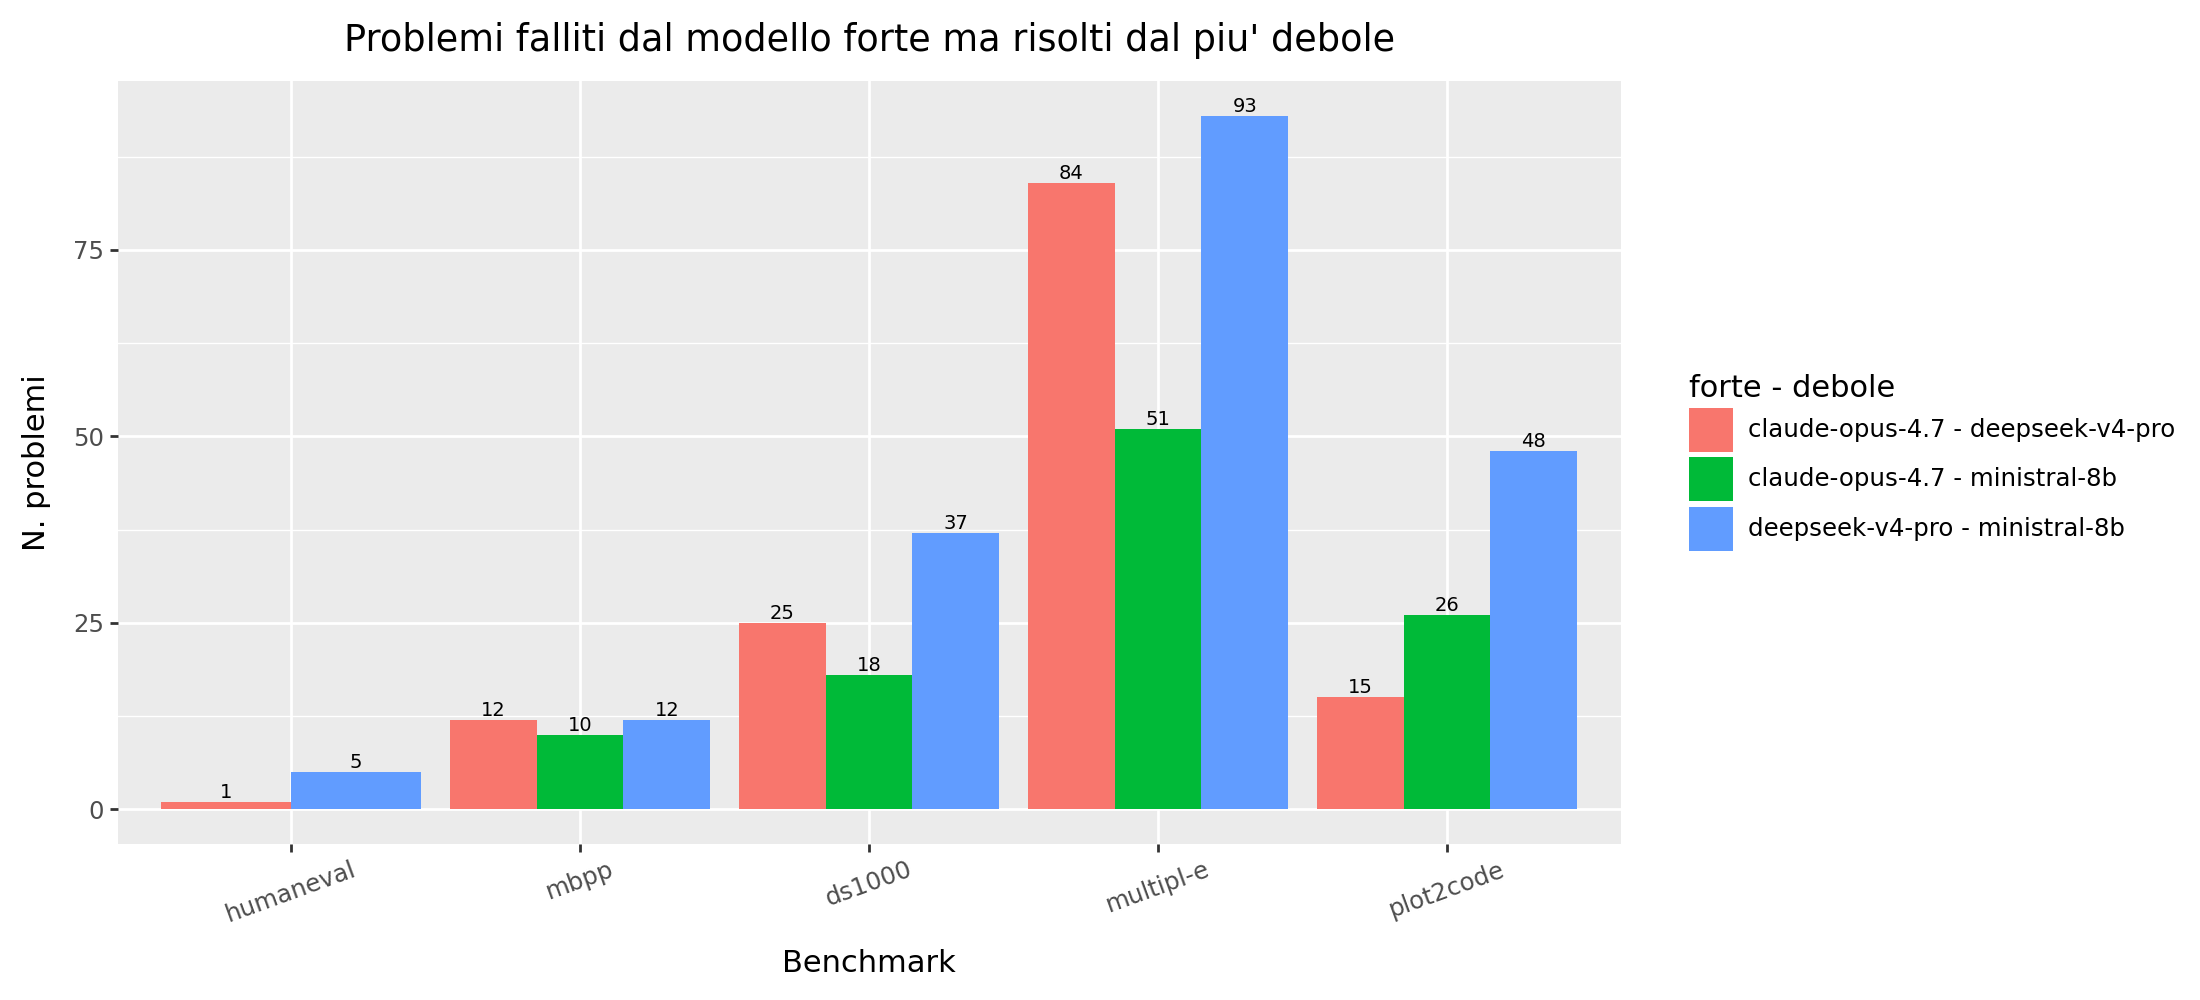

In [15]:
cross_plot = cross[cross["n"] > 0].copy()
cross_plot["coppia"] = cross_plot["forte"] + " - " + cross_plot["debole"]
cross_plot["benchmark"] = pd.Categorical(cross_plot["benchmark"], BENCHMARKS, ordered=True)

p_cross = (
    ggplot(cross_plot)
    + aes(x="benchmark", y="n", fill="coppia")
    + geom_bar(stat="identity", position=position_dodge(width=0.9))
    + geom_text(aes(label="n"), position=position_dodge(width=0.9),
                va="bottom", size=7)
    + labs(title="Problemi falliti dal modello forte ma risolti dal piu' debole",
           x="Benchmark", y="N. problemi", fill="forte - debole")
    + theme_gray()
    + theme(figure_size=(11, 5), axis_text_x=element_text(rotation=20))
)
p_cross


### 6.5 Esporta l'elenco dei casi "sorprendenti"
Lista dettagliata dei problemi che **claude** ha sbagliato ma che almeno un modello piu' debole ha
risolto, salvata in `analysis/claude_falliti_recuperati.csv` per ispezione manuale.

In [16]:
any_weak = failed_best[weaker].fillna(False).astype(bool).any(axis=1)
recovered = failed_best[any_weak].copy()
for w in weaker:
    recovered[f"risolto_{w}"] = recovered[w].fillna(False).astype(bool)
cols = ["benchmark", "task_id"] + [f"risolto_{w}" for w in weaker]
recovered_out = recovered[cols].sort_values(["benchmark", "task_id"])

out_csv = Path.cwd() / "claude_falliti_recuperati.csv"
recovered_out.to_csv(out_csv, index=False)
print(f"{len(recovered_out)} problemi salvati in {out_csv.name}")
recovered_out.head(15)


180 problemi salvati in claude_falliti_recuperati.csv


model,benchmark,task_id,risolto_deepseek-v4-pro,risolto_ministral-8b
11,ds1000,11,True,False
27,ds1000,27,True,False
60,ds1000,60,True,False
129,ds1000,129,False,True
206,ds1000,206,True,True
208,ds1000,208,True,False
215,ds1000,215,True,True
219,ds1000,219,True,True
234,ds1000,234,True,False
236,ds1000,236,True,True


## 7. Tipologie di errore sui problemi non risolti

Per i problemi **non** risolti, la colonna `pass@1` contiene il tipo di errore (es. `AssertionError`,
`SyntaxError`, ...). Analizziamo, per ogni **modello** e **benchmark**, la distribuzione completa di
**tutte** le tipologie di errore.

### 7.1 Tabella completa: conteggio di ogni tipologia di errore per modello x benchmark
Una riga per coppia modello/benchmark, una colonna per **ogni** tipo di errore presente nei dati
(piu' la colonna `Totale` = totale problemi non risolti). Le colonne sono ordinate dalla tipologia
piu' frequente alla piu' rara.

In [17]:
err = data[~data["solved"]].copy()
err["errore"] = err["pass@1"].astype(str)

# ordine colonne = tipi di errore dal piu' frequente al piu' raro (sul totale)
ordine_err = err["errore"].value_counts().index.tolist()

# crosstab: (modello, benchmark) x tipo di errore
tab_err = (
    pd.crosstab([err["model"], err["benchmark"]], err["errore"])
      .reindex(columns=ordine_err, fill_value=0)
)
# ordina le righe come MODELS x BENCHMARKS
row_order = [(m, b) for m in MODELS for b in BENCHMARKS]
tab_err = tab_err.reindex(row_order, fill_value=0)
tab_err["Totale"] = tab_err.sum(axis=1)
tab_err.index.names = ["model", "benchmark"]
tab_err


errore                     AssertionError  SyntaxError  RuntimeError  ImportError  TypeError  AttributeError  ValueError  NameError  KeyError  IndexError  TimeoutError  \
model           benchmark                                                                                                                                                 
claude-opus-4.7 humaneval               1            0             0            0          0               0           0          0         0           0             0   
                mbpp                   39            1             0            0          0               0           0          1         0           0             0   
                ds1000                106            3             2            6         27              16           5          2         1           0             0   
                multipl-e             183          111            31            1          0               0           0          0         0           0             3   
                plot2code               0            2             1           58          1               1           2          0         3           0             0   
deepseek-v4-pro humaneval               9            0             0            0          1               0           0          5         0           0             0   
                mbpp                   87            0             0            0          0               0           0          1         0           0             0   
                ds1000                236            0             6            6         40              30          13         22         9           4             0   
                multipl-e             320          130            83            1          0               0           0          9         0           0             3   
                plot2code               0            1             4           71          0               8           8          1        13           1             0   
ministral-8b    humaneval              32            0             0            0          3               1           0          2         0           1             0   
                mbpp                  154            0             1            0          3               0           1          2         0           2             1   
                ds1000                320            8            17           13         72              54          55         49        10          13             0   
                multipl-e             559          306           162            1          9               0           0         12         0           1             5   
                plot2code               0            7            23           28         23              15          40          1         9           3             1   

errore                     IndentationError  EmptyOutput  NoFigure  Totale  
model           benchmark                                                   
claude-opus-4.7 humaneval                 0            0         0       1  
                mbpp                      0            0         0      41  
                ds1000                    5            0         0     173  
                multipl-e                 0            1         0     330  
                plot2code                 0            0         0      68  
deepseek-v4-pro humaneval                 1            0         0      16  
                mbpp                      0            0         0      88  
                ds1000                    1            0         0     367  
                multipl-e                 0            0         0     546  
                plot2code                 0            0         0     107  
ministral-8b    humaneval                 0            0         0      39  
                mbpp                      0            0         0     164  
              

### 7.2 Riga di totale per tipologia di errore (su tutti i modelli e benchmark)
Quante volte compare in assoluto ogni tipo di errore.

In [18]:
totali_errore = (
    err["errore"].value_counts()
       .rename_axis("tipo_errore").reset_index(name="conteggio")
)
totali_errore["%_sui_non_risolti"] = (
    100 * totali_errore["conteggio"] / totali_errore["conteggio"].sum()
).round(1)
totali_errore


,tipo_errore,conteggio,%_sui_non_risolti
0,AssertionError,2046,54.4
1,SyntaxError,569,15.1
2,RuntimeError,330,8.8
3,ImportError,185,4.9
4,TypeError,179,4.8
5,AttributeError,125,3.3
6,ValueError,124,3.3
7,NameError,107,2.8
8,KeyError,45,1.2
9,IndexError,25,0.7


### 7.3 Errore piu' frequente per modello x benchmark (sintesi)
Per ogni cella: la tipologia dominante e (tra parentesi) quante volte compare.

In [19]:
dom = (err.groupby(["model", "benchmark", "errore"]).size().reset_index(name="n")
          .sort_values("n", ascending=False)
          .groupby(["model", "benchmark"], as_index=False).head(1))
dom["cella"] = dom["errore"] + " (" + dom["n"].astype(str) + ")"
errore_dominante = (
    dom.pivot(index="model", columns="benchmark", values="cella")
       .reindex(index=MODELS, columns=BENCHMARKS)
)
errore_dominante


benchmark,humaneval,mbpp,ds1000,multipl-e,plot2code
model,,,,,
claude-opus-4.7,AssertionError (1),AssertionError (39),AssertionError (106),AssertionError (183),ImportError (58)
deepseek-v4-pro,AssertionError (9),AssertionError (87),AssertionError (236),AssertionError (320),ImportError (71)
ministral-8b,AssertionError (32),AssertionError (154),AssertionError (320),AssertionError (559),ValueError (40)


## 8. Plot2Code: similarita' immagine di riferimento vs immagine generata

Per Plot2Code il confronto e' tra il grafico **di riferimento** e quello **generato** dal modello.
La metrica principale e' **`img_visual`** (composite di `image_similarity.py`), media pesata di:
`text_match` (OCR, peso 0.4), `ssim` (struttura, 0.4), `color_sim` (colore, 0.2); tutte in [0,1],
1 = identiche. Mostriamo anche **SSIM** e **color** come scomposizione.

> **Nota.** Nei run la componente OCR (`img_text`) non e' disponibile (motore Tesseract assente):
> e' quindi `n/d` e il composite rinormalizza sui pesi rimanenti, ossia
> `img_visual = (2*ssim + color) / 3` (struttura + colore, senza testo).
> Le metriche immagine hanno senso solo sui grafici che **renderizzano** (`pass@1 == passed`).

### 8.1 Tabella riassuntiva delle metriche immagine per modello

In [20]:
p2c = data[data["benchmark"] == "plot2code"].copy()
for col in ["img_visual", "img_ssim", "img_color", "img_text", "codebleu"]:
    p2c[col] = pd.to_numeric(p2c[col], errors="coerce")

ok = p2c[p2c["solved"]]                     # solo i grafici che renderizzano
tot_per_model = p2c.groupby("model").size()

plot2code_metriche = ok.groupby("model").agg(
    img_visual_medio=("img_visual", "mean"),
    ssim_medio=("img_ssim", "mean"),
    color_medio=("img_color", "mean"),
    ocr_medio=("img_text", "mean"),
).reindex(MODELS).round(3)

plot2code_metriche.insert(
    0, "render (ok/tot)",
    ok.groupby("model").size().reindex(MODELS).astype(int).astype(str)
    + " / " + tot_per_model.reindex(MODELS).astype(int).astype(str),
)
# OCR non disponibile -> n/d
plot2code_metriche["ocr_medio"] = plot2code_metriche["ocr_medio"].astype("object").where(
    plot2code_metriche["ocr_medio"].notna(), "n/d")
plot2code_metriche


,render (ok/tot),img_visual_medio,ssim_medio,color_medio,ocr_medio
model,,,,,
claude-opus-4.7,300 / 368,0.687,0.785,0.492,n/d
deepseek-v4-pro,261 / 368,0.632,0.729,0.438,n/d
ministral-8b,217 / 368,0.549,0.682,0.283,n/d


### 8.2 Scatterplot: similarita' immagine (`img_visual`) vs similarita' codice (`codebleu`)
Un punto per ogni grafico renderizzato. Serve a capire se un codice piu' simile al riferimento
(`codebleu` alto) produce anche un'immagine piu' simile (`img_visual` alto). Una facet per modello;
in sottotitolo la correlazione di Pearson r.

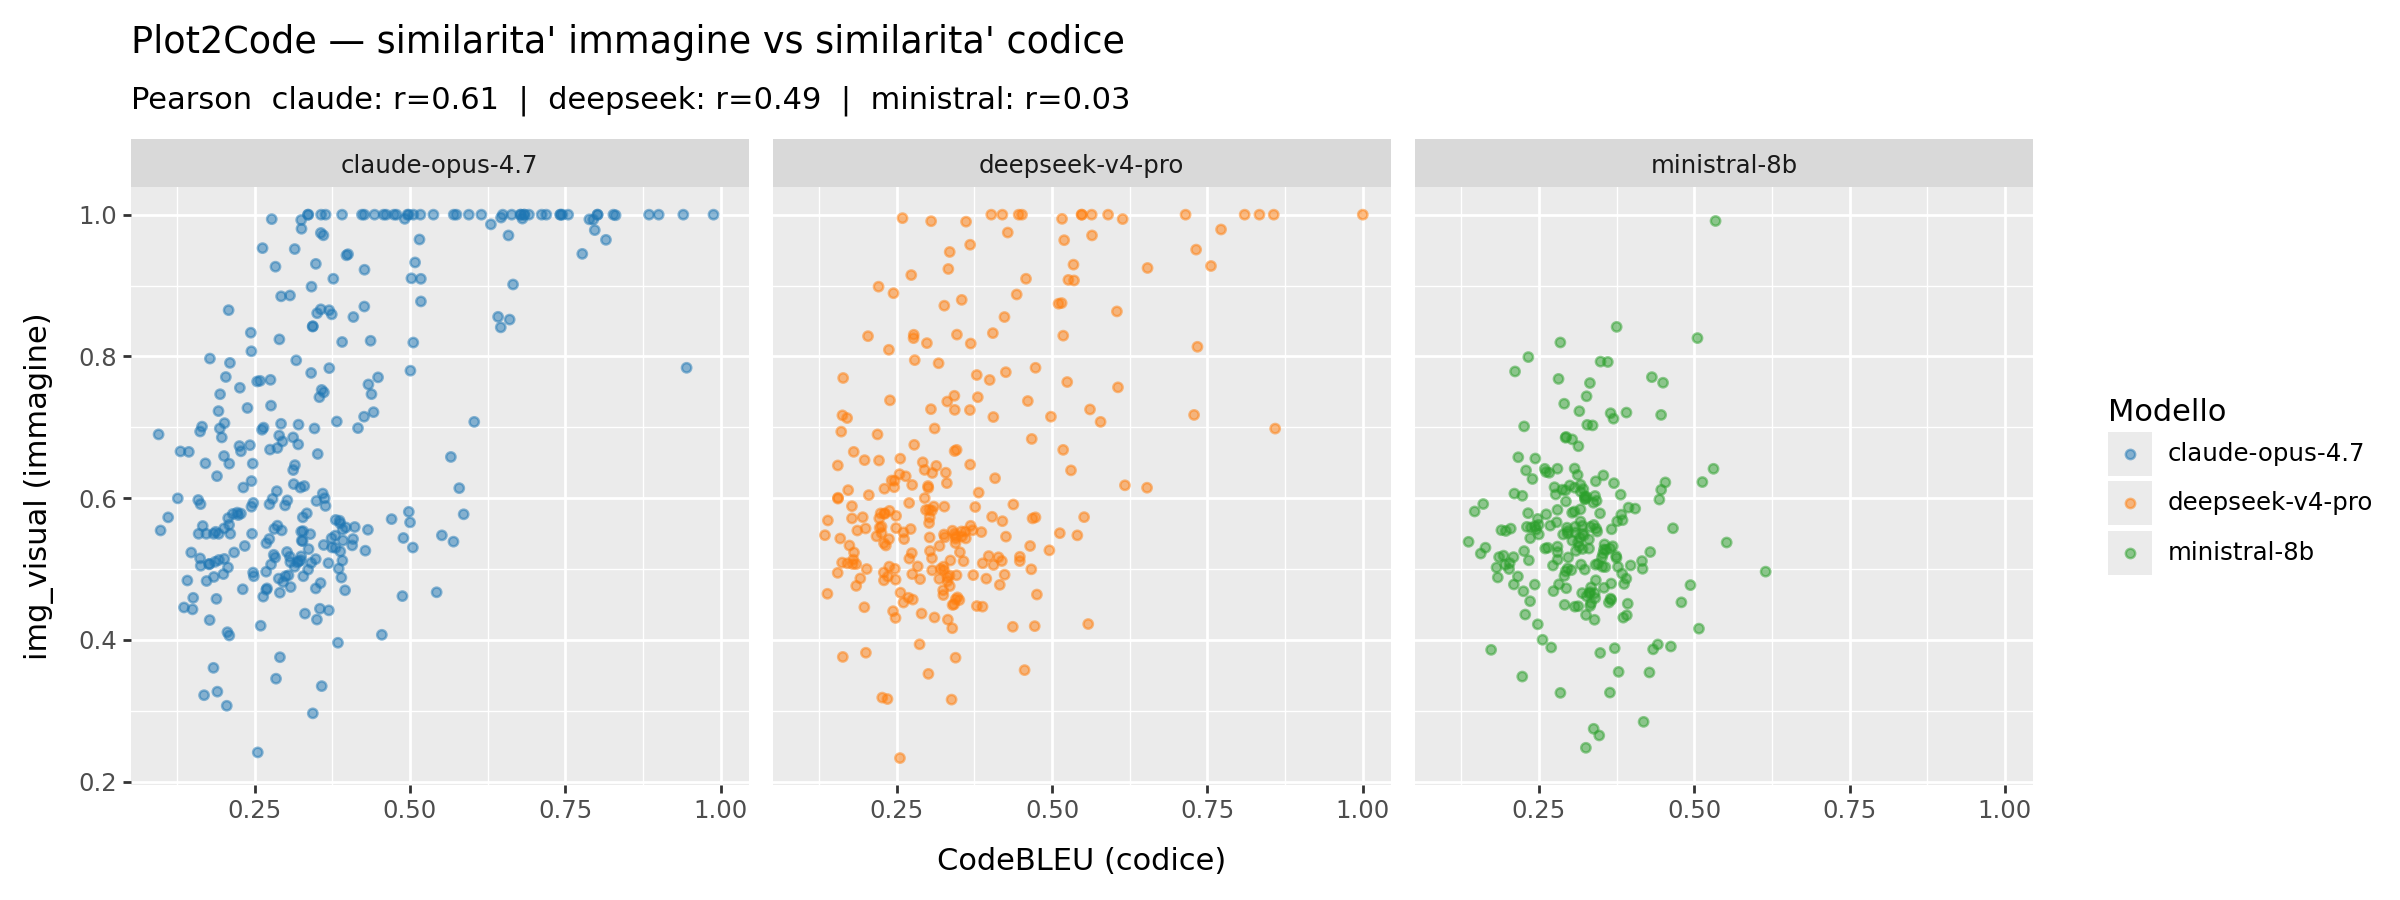

In [21]:
sc = p2c[p2c["solved"]].dropna(subset=["codebleu", "img_visual"]).copy()
sc["model"] = pd.Categorical(sc["model"], MODELS, ordered=True)

# correlazione di Pearson per modello (mostrata nel sottotitolo)
corr = sc.groupby("model", observed=True).apply(
    lambda d: d["codebleu"].corr(d["img_visual"]))
corr_txt = "  |  ".join(f"{m.split('-')[0]}: r={corr[m]:.2f}" for m in MODELS)

MODEL_COLORS = {"claude-opus-4.7": "#1f77b4",
                "deepseek-v4-pro": "#ff7f0e",
                "ministral-8b": "#2ca02c"}

p_p2c = (
    ggplot(sc)
    + aes(x="codebleu", y="img_visual", color="model")
    + geom_point(alpha=0.5, size=1.4)
    + facet_wrap("model", ncol=3)
    + scale_color_manual(values=MODEL_COLORS)
    + labs(title="Plot2Code — similarita' immagine vs similarita' codice",
           subtitle="Pearson  " + corr_txt,
           x="CodeBLEU (codice)", y="img_visual (immagine)", color="Modello")
    + theme_gray()
    + theme(figure_size=(12, 4.5))
)
p_p2c


---
**Note**
- `solved` = `pass@1 == "passed"`.
- CodeBLEU non e' calcolato per MultiPL-E (multilinguaggio, senza soluzione gold) -> escluso dagli scatterplot.
- Le icone dei linguaggi provengono da [icons8](https://icons8.com); `lua` ha fallback testuale.
